In [567]:
%pip install networkx
%pip install torch-geometric
%pip install node2vec

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
  Using cached node2vec-0.5.0-py3-none-any.whl.metadata (849 bytes)
  Using cached gensim-4.4.0-cp313-cp313-win_amd64.whl.metadata (8.6 kB)
  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'
Note: you ma

  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      + c:\ProgramData\anaconda3\python.exe C:\Users\32451\AppData\Local\Temp\pip-install-aelagxsh\numpy_0aeff12b51164a489210fb625b6a6d0b\vendored-meson\meson\meson.py setup C:\Users\32451\AppData\Local\Temp\pip-install-aelagxsh\numpy_0aeff12b51164a489210fb625b6a6d0b C:\Users\32451\AppData\Local\Temp\pip-install-aelagxsh\numpy_0aeff12b51164a489210fb625b6a6d0b\.mesonpy-8mqzv933 -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\32451\AppData\Local\Temp\pip-install-aelagxsh\numpy_0aeff12b51164a489210fb625b6a6d0b\.mesonpy-8mqzv933\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.99
      Source dir: C:\Users\32451\AppData\Local\Temp\pip-install-aelagxsh\numpy_0aeff12b51164a489210fb625b6a6d0b
      Build dir: C:\Users\32451\AppData\Local\Temp\pip-install-aelagxsh\numpy_0aeff12b51164a4892

In [568]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu126
Note: you may need to restart the kernel to use updated packages.


In [569]:
%pip install python-louvain

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [570]:
# ---------------------- #
# General Kaggle imports #
# ---------------------- #

import os
for dirname, _, filenames in os.walk('/kaggle/input'): 
    for filename in filenames:
        print(os.path.join(dirname, filename))

import numpy as np
import pandas as pd        


# ------------------ #
# Additional imports #
# ------------------ #
import random
import torch
import torch_geometric

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import community as community_louvain
import torch.nn.functional as F


from torch import Tensor
from torch_geometric.nn import GCNConv, GATConv
from sklearn.metrics import (
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix, 
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from torch_geometric.data import Data 
from scipy.stats import ttest_ind

print("Torch version:", torch.__version__)
print("Torch Geometric version:", torch_geometric.__version__)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=mpl.MatplotlibDeprecationWarning)

Torch version: 2.9.1+cu126
Torch Geometric version: 2.7.0


In [571]:
# !nvcc --version

<img src="https://www.bitcoinsistemi.com/wp-content/uploads/2023/12/bitcoin.jpg" alt="Bitcoin Graph Image" width="800"/>

# 💰Bitcoin Transactions 🔗 Graph Neural Networks 🪙

This notebook tackles [Kaggles Elliptic Bitcoin Transaction Dataset](https://www.kaggle.com/datasets/ellipticco/elliptic-data-set/data) which maps Bitcoin transactions to real entities. In the description the objective for this dataset is described as:
> classifying the illicit and licit nodes in the graph.

[Wikipedia describes Bitcoin](https://en.wikipedia.org/wiki/Bitcoin) as the first decentralized cryptocurrency. It also states that nodes in the Bitcoin network verify transactions through cryptography and record them in a public distributed ledger, called _blockchain_. The dataset we are going to work on in this notebook is an anonymized transaction graph collexted from such Bitcoin blockchain. Kaggles Data Card describes the dataset as having the following content: 

__Dataset Content__
- _Node_: represents a transaction. 
    - Each has 166 features
    - Labeled as ✅ _licit_, ❌ _illicit_ or 🤷 _unknown_
- _Edge_: represents a flow of Bitcoins between transaction `A` and transaction `B` 

Before we start, here are a couple concepts you should know for better understanding of the following code: 

| Concept | Math Notation | Description | More Information | 
| ------- | ------------- | ----------- | ---------------- |
| Graph | $G$ | Defined as pair $G=(V,E)$, where $V$ is a set of vertices and $E$ is a set of edges which are unordered pairs ${v_1, v_2}$ of vertices. | [Wikipedia: Graph (discrete mathematics)](https://en.wikipedia.org/wiki/Graph_(discrete_mathematics)) | 
| Degree | $deg$ | Number of edges that are incident to a vertex. | [Wikipedia: Degree (graph theory)](https://en.wikipedia.org/wiki/Degree_(graph_theory)) | 
| Component | | Connected subgraph that is not part of any larger connected subgraph. | [Wikipedia: Component (graph theory](https://en.wikipedia.org/wiki/Component_(graph_theory)) | 

🚨 In the following notebook we will always call the graph $G$, the set of nodes $V$ and the set of edges $E$. 🚨

# ⚙️ Global Settings

In [572]:
RANDOM_STATE = 42
NUM_EPOCHS = 100

In [573]:
def set_seed_for_torch(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)      # For single-GPU.
        torch.cuda.manual_seed_all(seed)  # For multi-GPU.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
def set_seed_for_numpy(seed):
    np.random.seed(seed) 
    
def set_seed_for_random(seed):
    random.seed(seed)    

In [574]:
set_seed_for_torch(RANDOM_STATE)
set_seed_for_numpy(RANDOM_STATE)
set_seed_for_random(RANDOM_STATE)

# 🛠️ Helper Methods

In [575]:
from torch_geometric.loader import NeighborLoader # hey James, I added this for you

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# def train_gnn(num_epochs, data, model, optimizer, criterion):
    
#     train_losses = []
#     train_accuracies = []
#     train_precisions = []
#     train_recalls = []
#     train_f1_scores = []

#     val_accuracies = []
#     val_precisions = []
#     val_recalls = []
#     val_f1_scores = []

#     # ----- #
#     # Train #
#     # ----- #

#     for epoch in range(1, num_epochs + 1):
#         model.train()
#         optimizer.zero_grad()
#         out = model(data)
#         loss = criterion(out[data.train_mask], 
#                          data.y[data.train_mask])
#         loss.backward()
#         optimizer.step()

#         # --- Calculate training metrics ---
#         pred_train = out[data.train_mask].argmax(dim=1)
#         correct_train = (pred_train == data.y[data.train_mask]).sum()
#         train_acc = int(correct_train) / int(data.train_mask.sum())
#         train_accuracies.append(train_acc)

#         y_true_train = data.y[data.train_mask].cpu().numpy()
#         y_pred_train = pred_train.cpu().numpy()

#         train_prec = precision_score(y_true_train, y_pred_train, average='weighted', zero_division=0)
#         train_rec = recall_score(y_true_train, y_pred_train, average='weighted', zero_division=0)
#         train_f1 = f1_score(y_true_train, y_pred_train, average='weighted', zero_division=0)

#         train_precisions.append(train_prec)
#         train_recalls.append(train_rec)
#         train_f1_scores.append(train_f1)
#         train_losses.append(loss.item())

#         # --- Validate and calculate validation metrics ---
#         model.eval()
#         with torch.no_grad():
#             out = model(data)
#             pred_val = out[data.val_mask].argmax(dim=1)
#             correct_val = (pred_val == data.y[data.val_mask]).sum()
#             val_acc = int(correct_val) / int(data.val_mask.sum())
#             val_accuracies.append(val_acc)

#             y_true_val = data.y[data.val_mask].cpu().numpy()
#             y_pred_val = pred_val.cpu().numpy()

#             val_prec = precision_score(y_true_val, y_pred_val, average='weighted', zero_division=0)
#             val_rec = recall_score(y_true_val, y_pred_val, average='weighted', zero_division=0)
#             val_f1 = f1_score(y_true_val, y_pred_val, average='weighted', zero_division=0)

#             val_precisions.append(val_prec)
#             val_recalls.append(val_rec)
#             val_f1_scores.append(val_f1)

#         if epoch % 10 == 0:        
#             print(f'Epoch {epoch:03d}, Loss: {loss:.4f}, Train - Acc: {train_acc:.4f} - Prec: {train_prec:.4f} - Rec: {train_rec:.4f} - F1: {train_f1:.4f}')
#             print(f'                         Val   - Acc: {val_acc:.4f} - Prec: {val_prec:.4f} - Rec: {val_rec:.4f} - F1: {val_f1:.4f}')        

#     return {
#         'train': {
#             'losses': train_losses,
#             'accuracies': train_accuracies,
#             'precisions': train_precisions,
#             'recalls': train_recalls,
#             'f1_scores': train_f1_scores,
#         },
#         'val': {
#             'accuracies': val_accuracies,
#             'precisions': val_precisions,
#             'recalls': val_recalls,
#             'f1_scores': val_f1_scores,            
#         }
#     }

In [ ]:
# def plot_train_val_test_metrics(train_val_metrics, test_metrics, num_epochs):
#     plt.figure(figsize=(10, 6))

#     # --- Accuracy ----
#     plt.subplot(2, 2, 1)
#     plt.plot(range(1, num_epochs + 1), train_val_metrics['train']['accuracies'], color='C0', linewidth=1.0, label='Training')
#     plt.plot(range(1, num_epochs + 1), train_val_metrics['val']['accuracies'], color='C1', linewidth=1.0, label='Validation', linestyle=':')
#     plt.axhline(y=test_metrics['accuracy'], color='C2', linewidth=0.5, linestyle='--', label='Test')
#     plt.xlabel('Epoch')
#     plt.ylabel('Accuracy')
#     plt.legend(fontsize=8)
#     plt.title('Accuracy')

#     # --- Precision ---
#     plt.subplot(2, 2, 2)
#     plt.plot(range(1, num_epochs + 1), train_val_metrics['train']['precisions'], color='C0', linewidth=1.0, label='Training')
#     plt.plot(range(1, num_epochs + 1), train_val_metrics['val']['precisions'], color='C1', linewidth=1.0, label='Validation', linestyle=':')
#     plt.axhline(y=test_metrics['precision'], color='C2', linewidth=0.5, linestyle='--', label='Test')
#     plt.xlabel('Epoch')
#     plt.ylabel('Precision')
#     plt.legend(fontsize=8)
#     plt.title('Precision')

    # # --- Recall ---
    # plt.subplot(2, 2, 3)
    # plt.plot(range(1, num_epochs + 1), train_val_metrics['train']['recalls'], color='C0', linewidth=1.0, label='Training')
    # plt.plot(range(1, num_epochs + 1), train_val_metrics['val']['recalls'], color='C1', linewidth=1.0, label='Validation', linestyle=':')
    # plt.axhline(y=test_metrics['recall'], color='C2', linewidth=0.5, linestyle='--', label='Test')
    # plt.xlabel('Epoch')
    # plt.ylabel('Recall')
    # plt.legend(fontsize=8)
    # plt.title('Recall')

    # # --- F1-Score ---
    # plt.subplot(2, 2, 4)
    # plt.plot(range(1, num_epochs + 1), train_val_metrics['train']['f1_scores'], linewidth=1.0, color='C0', label='Training')
    # plt.plot(range(1, num_epochs + 1), train_val_metrics['val']['f1_scores'], linewidth=1.0, color='C1', label='Validation', linestyle=':')
    # plt.axhline(y=test_metrics['f1_score'], color='C2', linewidth=0.5, linestyle='--', label='Test')
    # plt.xlabel('Epoch')
    # plt.ylabel('F1-Score')
    # plt.legend(fontsize=8)
    # plt.title('F1-Score')

    # plt.tight_layout()
    # plt.show()

In [578]:

def train_minibatch(model, optimizer, train_loader, criterion):
    """
    One epoch of mini-batch training using NeighborLoader.
    Loss is computed only on the seed nodes in each batch.
    """
    model.train()
    total_loss = 0.0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        # forward pass on the sampled subgraph
        out = model(batch)                     # out shape: [num_batch_nodes, 3]

        # only supervise on the "seed" nodes (first batch.batch_size entries)
        logits_seed = out[:batch.batch_size]
        labels_seed = batch.y[:batch.batch_size]

        loss = criterion(logits_seed, labels_seed)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

# 📜 Overview

Let's start by getting an overview of the datasets.

In [579]:
elliptic_txs_features = pd.read_csv('elliptic_txs_features.csv', header=None)
elliptic_txs_classes = pd.read_csv('elliptic_txs_classes.csv')
elliptic_txs_edgelist = pd.read_csv('elliptic_txs_edgelist.csv')

elliptic_txs_features.columns = ['txId'] + [f'V{i}' for i in range(1, 167)]

print(f"""Shapes
{4*' '}Features : {elliptic_txs_features.shape[0]:8,} (rows)  {elliptic_txs_features.shape[1]:4,} (cols)
{4*' '}Classes  : {elliptic_txs_classes.shape[0]:8,} (rows)  {elliptic_txs_classes.shape[1]:4,} (cols)
{4*' '}Edgelist : {elliptic_txs_edgelist.shape[0]:8,} (rows)  {elliptic_txs_edgelist.shape[1]:4,} (cols)
""")

Shapes
    Features :  203,769 (rows)   167 (cols)
    Classes  :  203,769 (rows)     2 (cols)
    Edgelist :  234,355 (rows)     2 (cols)



__Nodes & Edges__

- $|V| = 203,768$ (number of nodes in $G$)
- $|E| = 234,355$ (number of edges in $G$)

In [580]:
elliptic_txs_features.head(3)  # Dataset containing the node features.

,txId,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792


In [581]:
elliptic_txs_classes.head(3)  # Dataset containing the classes of the node.

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown


In [582]:
elliptic_txs_edgelist.head(3)  # Dataset containing the edges.

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870


Let's get an overview on the distribution of the `class`es. 

In [583]:
elliptic_txs_classes['class_mapped'] = elliptic_txs_classes['class'].replace({'1': 'illicit', '2': 'licit'})

percentage_distribution = round(100 * elliptic_txs_classes['class_mapped'].value_counts(normalize=True), 2)
class_counts = elliptic_txs_classes['class_mapped'].value_counts()

emoji_mapping = {'licit': '✅', 'illicit': '❌', 'unknown': '🤷'}
elliptic_txs_classes['emoji'] = elliptic_txs_classes['class_mapped'].map(emoji_mapping)

classes_df = pd.DataFrame({
    'Class Mapped': elliptic_txs_classes['class_mapped'].unique(),
    'Class Raw': elliptic_txs_classes['class'].unique(),    
    'Counts': class_counts.values,
    'Percentage': percentage_distribution.values,
    'Emoji': [emoji_mapping[class_label] for class_label in elliptic_txs_classes['class_mapped'].unique()]
})
classes_df

,Class Mapped,Class Raw,Counts,Percentage,Emoji
0,unknown,unknown,157205,77.15,🤷
1,licit,2,42019,20.62,✅
2,illicit,1,4545,2.23,❌


- 77.15% of all classes are `unknown`
- 20.62% of all classes are `licit` (2)
- 2.23% of all classes are `illicit` (1)

In [584]:
num_nodes = elliptic_txs_features.shape[0]
num_edges = elliptic_txs_edgelist.shape[0]

print(f"Number of nodes: {num_nodes:,}")
print(f"Number of edges: {num_edges:,}")

Number of nodes: 203,769
Number of edges: 234,355


In [585]:
# Create graph from the edgelist.
G = nx.from_pandas_edgelist(elliptic_txs_edgelist, 'txId1', 'txId2')

In [586]:
# Sampling for easier analysis...for now.
classes_sampled = elliptic_txs_classes.groupby('class_mapped').sample(frac=0.05, random_state=RANDOM_STATE)
txIds_sampled = classes_sampled['txId']

# Filter elliptic_txs_edgelist based on the sampled txIds
edgelist_sampled = elliptic_txs_edgelist[
    elliptic_txs_edgelist['txId1'].isin(txIds_sampled) | elliptic_txs_edgelist['txId2'].isin(txIds_sampled)
]

# Filter elliptic_txs_features based on the sampled txIds
features_sampled = elliptic_txs_features[elliptic_txs_features['txId'].isin(txIds_sampled)]

print(f"Sampled Classes:\n{classes_sampled['class_mapped'].value_counts()}\n")
print(f"Sampled Edgelist: {edgelist_sampled.shape[0]:,}")
print(f"Sampled Features: {features_sampled.shape[0]:,}")

Sampled Classes:
class_mapped
unknown    7860
licit      2101
illicit     227
Name: count, dtype: int64

Sampled Edgelist: 23,051
Sampled Features: 10,188


# 🔍 Exploratory Data Analysis (EDA) 

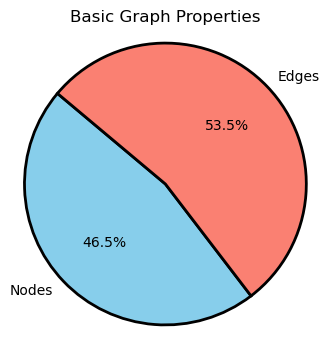

In [587]:
plt.figure(figsize=(4, 4))
sizes = [num_nodes, num_edges]
labels = ['Nodes', 'Edges']
colors = ['skyblue', 'salmon']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, 
        wedgeprops = {'edgecolor' : 'black', 
                      'linewidth': 2, 
                      'antialiased': True})
plt.title('Basic Graph Properties')
plt.axis('equal')
plt.show()

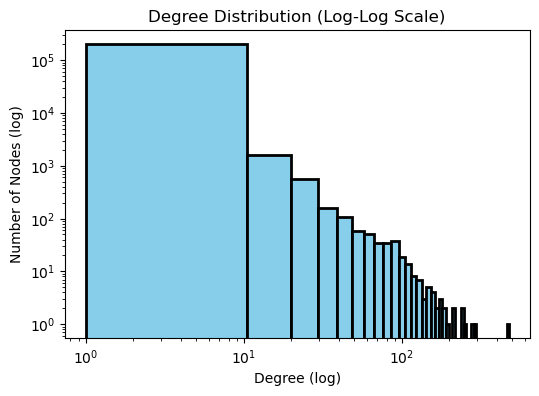

In [588]:
# --- Degree Distribution (Log-Log Scale) ---
plt.figure(figsize=(6, 4))
degrees = [G.degree(n) for n in G.nodes()]
plt.hist(degrees, bins=50, log=True, color='skyblue', edgecolor='black', linewidth=2.0)
plt.xscale('log')
plt.yscale('log')
plt.title('Degree Distribution (Log-Log Scale)')
plt.xlabel('Degree (log)')
plt.ylabel('Number of Nodes (log)')
plt.show()

## 📊 Basic Statistics

Number of nodes: 10,188
Number of edges: 23,051


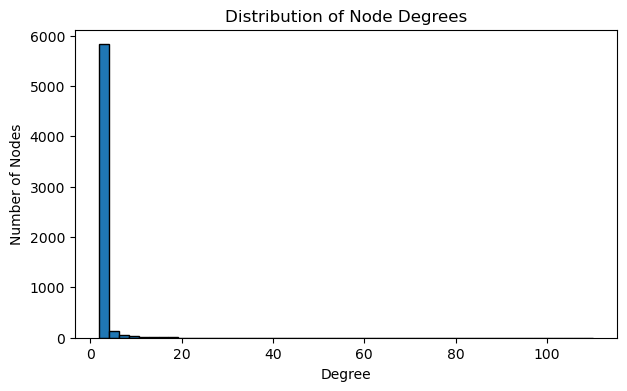

In [589]:
# Number of nodes and edges
num_nodes = features_sampled.shape[0]
num_edges = edgelist_sampled.shape[0]

print(f"Number of nodes: {num_nodes:,}")
print(f"Number of edges: {num_edges:,}")

# Distribution of node degrees
plt.figure(figsize=(7, 4))

node_degrees = edgelist_sampled['txId1'].value_counts() + edgelist_sampled['txId2'].value_counts()
node_degrees.hist(bins=50, edgecolor='black')
plt.title('Distribution of Node Degrees')
plt.xlabel('Degree')
plt.ylabel('Number of Nodes')
plt.grid(False)
plt.show()

## 🔗 Graph Connectivity

In [590]:
# Create graph from the edgelist.
G = nx.from_pandas_edgelist(edgelist_sampled, 'txId1', 'txId2')

Number of connected components: 7297
Giant component - Number of nodes: 400
Giant component - Number of edges: 431


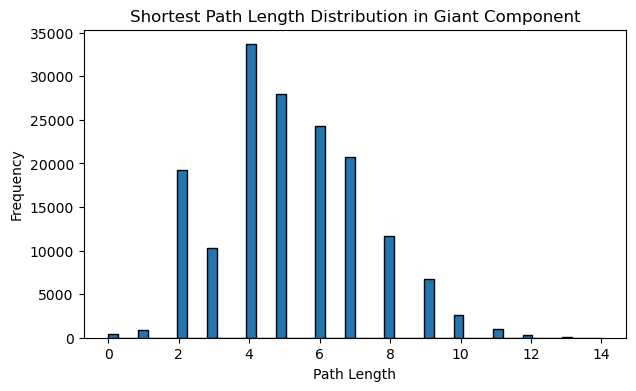

In [591]:
# --- Connected components ---
num_connected_components = nx.number_connected_components(G)
print(f"Number of connected components: {num_connected_components}")

# --- Giant component analysis ---
giant_component = max(nx.connected_components(G), key=len)
G_giant = G.subgraph(giant_component)

print(f"Giant component - Number of nodes: {G_giant.number_of_nodes():,}")
print(f"Giant component - Number of edges: {G_giant.number_of_edges():,}")


# --------------------------------------------------------- #
# Shortest paths length distribution in the giant component #
# --------------------------------------------------------- #
path_lengths = dict(nx.shortest_path_length(G_giant))
path_lengths_values = [length for target_lengths in path_lengths.values() for length in target_lengths.values()]

plt.figure(figsize=(7, 4))
plt.hist(path_lengths_values, bins=50, edgecolor='black')
plt.title('Shortest Path Length Distribution in Giant Component')
plt.xlabel('Path Length')
plt.ylabel('Frequency')
plt.show()

## 🎯 Node Centrality Measures

In this section we are going to investigate node centrality measures. Such measures are used in graph theory to identify the most important or influential nodes within a network. We will focus on the following three centrality measures: 

___🔢 Degree Centrality___

**Definition:**
Degree centrality measures the number of direct connections a node has in a network. It is defined as the number of edges connected to a node.

**Mathematical Function:**
$$
\begin{aligned}
& C_D(v) = \frac{\text{deg}(v)}{N - 1} \\ 
& \text{Where:} \\
& \qquad \text{deg}(v) \; \text{is the degree of node} \; (v) \; \text{(i.e., the number of edges connected to the node).} \\
& \qquad N \; \text{is the total number of nodes in the network.}
\end{aligned}
$$

**Interpretation:**
A node with a high degree centrality is highly connected and may play a crucial role in the network by having direct interactions with many other nodes.

___🔀 Betweenness Centrality___

**Definition:**
Betweenness centrality measures the extent to which a node lies on the shortest paths between other nodes in the network.

**Mathematical Function:**
$$
\begin{aligned}
& C_B(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}} \\
& \text{Where:} \\
& \qquad \sigma_{st} \; \text{is the total number of shortest paths between nodes} \; (s) \; \text{and} \; (t). \\
& \qquad \sigma_{st}(v) \; \text{is the number of those paths that pass through node} \; (v).
\end{aligned}
$$

**Interpretation:**
A node with high betweenness centrality has significant control over the flow of information or resources in the network because it connects different parts of the network. It often indicates a node that is critical for communication.

___🌐 Closeness Centrality___

**Definition:**
Closeness centrality measures how close a node is to all other nodes in the network. It is the reciprocal of the sum of the shortest path distances from the node to all other nodes in the network.

**Mathematical Function:**
$$
\begin{aligned}
& C_C(v) = \frac{N-1}{\sum_{t \neq v} d(v, t)} \\
& \text{Where:} \\ 
& \qquad d(v, t) \; \text{is the shortest path distance between node} \; (v) \; \text{and node} \; (t). \\
& \qquad N \; \text{is the total number of nodes in the network.}
\end{aligned}
$$

**Interpretation:**
A node with high closeness centrality can quickly interact with all other nodes and can be an effective spreader of information or influence throughout the network.

---


Top 10 nodes by degree centrality:
        Node  Degree Centrality
0   22837965           0.275689
1   22837835           0.192982
2  279199578           0.030075
3    3807285           0.027569
4  279187194           0.027569
5   22837973           0.022556
6   90716926           0.022556
7    8128388           0.022556
8   22837808           0.020050
9   22838007           0.020050


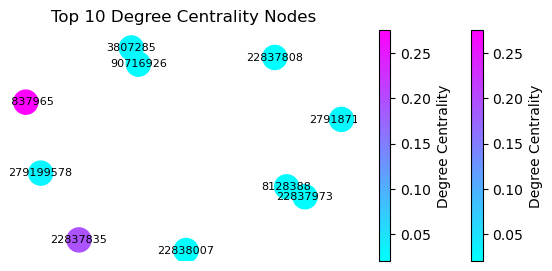

In [592]:
# Degree centrality.
degree_centrality = nx.degree_centrality(G_giant)
top_degree_centrality = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
df_top_degree_centrality = pd.DataFrame(top_degree_centrality, columns=['Node', 'Degree Centrality'])

print("Top 10 nodes by degree centrality:")
print("==================================")
print(df_top_degree_centrality)

top_nodes_by_ = df_top_degree_centrality['Node'].tolist()
subgraph = G_giant.subgraph(top_nodes_by_)
node_color = [degree_centrality[node] for node in subgraph.nodes()]
cmap = plt.cm.cool

# Compute positions for the subgraph (use seed for reproducibility).
pos_sub = nx.spring_layout(subgraph, seed=RANDOM_STATE)

# -------- #
# Plotting #
# -------- #
plt.figure(figsize=(7, 3))

# Draw nodes (draw_networkx_nodes returns a PathCollection which is mappable for colorbar).
nodes = nx.draw_networkx_nodes(
    subgraph,
    pos_sub,
    node_color=node_color,
    cmap=cmap,
    node_size=300,
    vmin=min(node_color),
    vmax=max(node_color)
)
nx.draw_networkx_edges(subgraph, pos_sub, edge_color='gray')
nx.draw_networkx_labels(subgraph, pos_sub, font_size=8)

plt.title('Top 10 Degree Centrality Nodes')
plt.colorbar(nodes, label='Degree Centrality')
plt.axis('off')
ax = plt.gca()
plt.colorbar(nodes, ax=ax, label='Degree Centrality')
ax.axis('off')
plt.show()

Top 10 nodes by betweenness centrality:
        Node  Betweenness Centrality
0   22837835                0.553959
1   22837965                0.491607
2   90716926                0.166458
3   22837784                0.165590
4  279187194                0.164591
5    3807285                0.144993
6    3097782                0.113509
7    8128388                0.103709
8    1435388                0.092219
9   21296808                0.086872


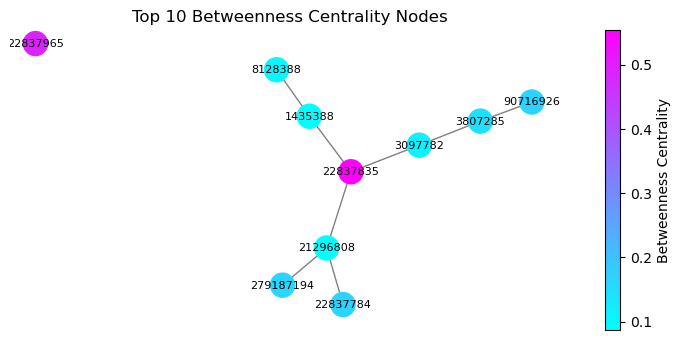

In [593]:
# Betweenness centrality.
betweenness_centrality = nx.betweenness_centrality(G_giant)
top_betweenness_centrality = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
df_top_betweenness_centrality = pd.DataFrame(top_betweenness_centrality, columns=['Node', 'Betweenness Centrality'])

print("Top 10 nodes by betweenness centrality:")
print("=======================================")
print(df_top_betweenness_centrality)

top_nodes_by_ = df_top_betweenness_centrality['Node'].tolist()
subgraph = G_giant.subgraph(top_nodes_by_)
node_color = [betweenness_centrality[node] for node in subgraph.nodes()]
norm = mpl.colors.Normalize(vmin=min(node_color), vmax=max(node_color))
node_color_normalized = [norm(value) for value in node_color]
cmap = plt.cm.cool

# -------- #
# Plotting #
# -------- #
plt.figure(figsize=(7, 3))

nx.draw(subgraph, with_labels=True, node_size=300, edge_color='gray', font_size=8, 
        node_color=node_color_normalized, cmap=cmap)
plt.title('Top 10 Betweenness Centrality Nodes')
plt.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=plt.gca(),
    label='Betweenness Centrality'
)
plt.show()

Top 10 nodes by closeness centrality:
        Node  Closeness Centrality
0   22837835              0.317928
1   22837965              0.293814
2    2203811              0.290605
3    1805107              0.285817
4   11447640              0.285817
5    2205152              0.285817
6    1367537              0.285817
7    1437191              0.285817
8   21296808              0.274038
9  279187194              0.271613


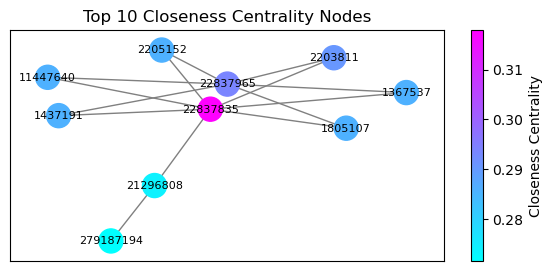

In [594]:
# Closeness centrality.
closeness_centrality = nx.closeness_centrality(G_giant)
top_closeness_centrality = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
df_top_closeness_centrality = pd.DataFrame(top_closeness_centrality, columns=['Node', 'Closeness Centrality'])

print("Top 10 nodes by closeness centrality:")
print("=====================================")
print(df_top_closeness_centrality)

top_nodes_by_closeness = df_top_closeness_centrality['Node'].tolist()
subgraph = G_giant.subgraph(top_nodes_by_closeness)
node_color = [closeness_centrality[node] for node in subgraph.nodes()]
norm = mpl.colors.Normalize(vmin=min(node_color), vmax=max(node_color))
node_color_normalized = [norm(value) for value in node_color]
cmap = plt.cm.cool

# -------- #
# Plotting #
# -------- #
plt.figure(figsize=(7, 3))

# Draw the subgraph nodes and edges. Use draw_networkx_nodes to get a mappable when possible.
nodes = nx.draw_networkx_nodes(
    subgraph,
    pos=nx.spring_layout(subgraph, seed=RANDOM_STATE),
    node_size=300,
    node_color=node_color_normalized,   # use normalized colors
    cmap=cmap
)
nx.draw_networkx_edges(subgraph, pos=nx.spring_layout(subgraph, seed=RANDOM_STATE), edge_color='gray')
nx.draw_networkx_labels(subgraph, pos=nx.spring_layout(subgraph, seed=RANDOM_STATE), font_size=8)

plt.title('Top 10 Closeness Centrality Nodes')

# Create a ScalarMappable and attach the colorbar to the current axes.
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # Needed for older matplotlib versions to avoid warnings.
plt.colorbar(sm, ax=plt.gca(), label='Closeness Centrality')

plt.show()

## 🖼️ Graph Visualization

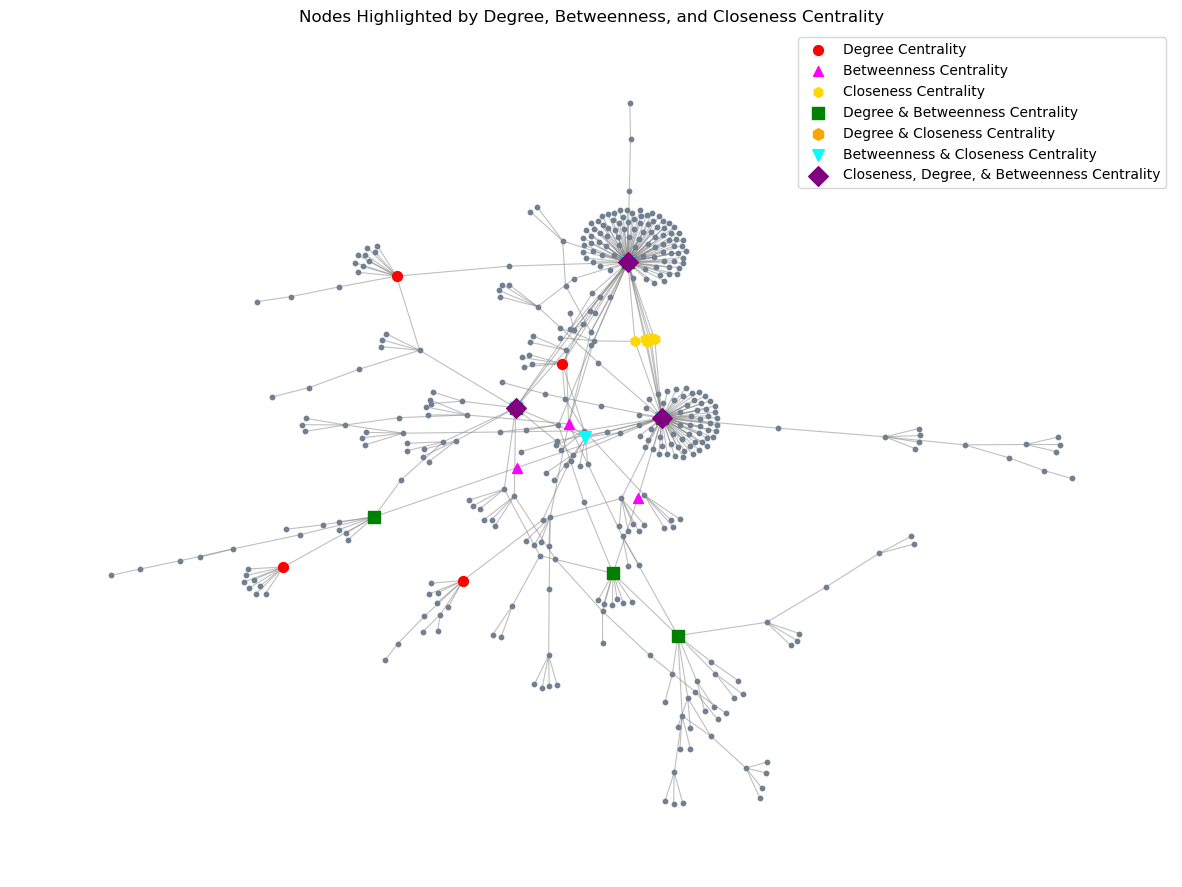

In [595]:
# --------- #
# Preparing #
# --------- #

# Identify nodes that are top in each centrality measure and their combinations.
top_nodes_degree = set([node for node, _ in top_degree_centrality])
top_nodes_betweenness = set([node for node, _ in top_betweenness_centrality])
top_nodes_closeness = set([node for node, _ in top_closeness_centrality])

top_nodes_both = top_nodes_degree.intersection(top_nodes_betweenness)
top_nodes_closeness_and_degree = top_nodes_closeness.intersection(top_nodes_degree)
top_nodes_closeness_and_betweenness = top_nodes_closeness.intersection(top_nodes_betweenness)
top_nodes_all_three = top_nodes_closeness.intersection(top_nodes_degree).intersection(top_nodes_betweenness)

# Assign colors and shapes based on centrality measures.
node_color = []
node_shape = []

for node in G_giant.nodes():
    if node in top_nodes_all_three:
        node_color.append('purple')
        node_shape.append('D')
    elif node in top_nodes_closeness_and_degree:
        node_color.append('orange')
        node_shape.append('h')
    elif node in top_nodes_closeness_and_betweenness:
        node_color.append('cyan')
        node_shape.append('v')
    elif node in top_nodes_both:
        node_color.append('green')
        node_shape.append('s')
    elif node in top_nodes_degree:
        node_color.append('red')
        node_shape.append('o')
    elif node in top_nodes_betweenness:
        node_color.append('magenta')
        node_shape.append('^')
    elif node in top_nodes_closeness:
        node_color.append('yellow')
        node_shape.append('h')
    else:
        node_color.append('slategrey')
        node_shape.append('o')

# -------- #
# Plotting #
# -------- #

plt.figure(figsize=(15, 11))

pos = nx.spring_layout(G_giant)
# Draw all nodes first.
nx.draw_networkx_nodes(G_giant, pos, node_color='slategrey', node_size=10)

# Draw nodes with specific centrality measures.
nx.draw_networkx_nodes(G_giant, pos, nodelist=list(top_nodes_degree - top_nodes_both - top_nodes_closeness_and_degree), 
                       node_color='red', node_size=50, node_shape='o', 
                       label='Degree Centrality')
nx.draw_networkx_nodes(G_giant, pos, nodelist=list(top_nodes_betweenness - top_nodes_both - top_nodes_closeness_and_betweenness), 
                       node_color='magenta', node_size=50, node_shape='^', 
                       label='Betweenness Centrality')
nx.draw_networkx_nodes(G_giant, pos, nodelist=list(top_nodes_closeness - top_nodes_closeness_and_degree - top_nodes_closeness_and_betweenness), 
                       node_color='gold', node_size=50, node_shape='h', 
                       label='Closeness Centrality')
nx.draw_networkx_nodes(G_giant, pos, nodelist=list(top_nodes_both), 
                       node_color='green', node_size=80, node_shape='s', 
                       label='Degree & Betweenness Centrality')
nx.draw_networkx_nodes(G_giant, pos, nodelist=list(top_nodes_closeness_and_degree), 
                       node_color='orange', node_size=70, node_shape='h', 
                       label='Degree & Closeness Centrality')
nx.draw_networkx_nodes(G_giant, pos, nodelist=list(top_nodes_closeness_and_betweenness), 
                       node_color='cyan', node_size=70, node_shape='v', 
                       label='Betweenness & Closeness Centrality')
nx.draw_networkx_nodes(G_giant, pos, nodelist=list(top_nodes_all_three), 
                       node_color='purple', node_size=100, node_shape='D', 
                       label='Closeness, Degree, & Betweenness Centrality')

# Draw edges.
nx.draw_networkx_edges(G_giant, pos, width=0.8, edge_color='gray', alpha=0.5)

plt.axis('off')
plt.title('Nodes Highlighted by Degree, Betweenness, and Closeness Centrality')
plt.legend(scatterpoints=1)
plt.show()

## 📈 Class-specific Analysis

In [596]:
# Class-based subgraphs.
illicit_nodes = classes_sampled[classes_sampled['class_mapped'] == 'illicit']['txId']
licit_nodes = classes_sampled[classes_sampled['class_mapped'] == 'licit']['txId']

G_illicit = G.subgraph(illicit_nodes)
G_licit = G.subgraph(licit_nodes)

In [597]:
classes_df

,Class Mapped,Class Raw,Counts,Percentage,Emoji
0,unknown,unknown,157205,77.15,🤷
1,licit,2,42019,20.62,✅
2,illicit,1,4545,2.23,❌


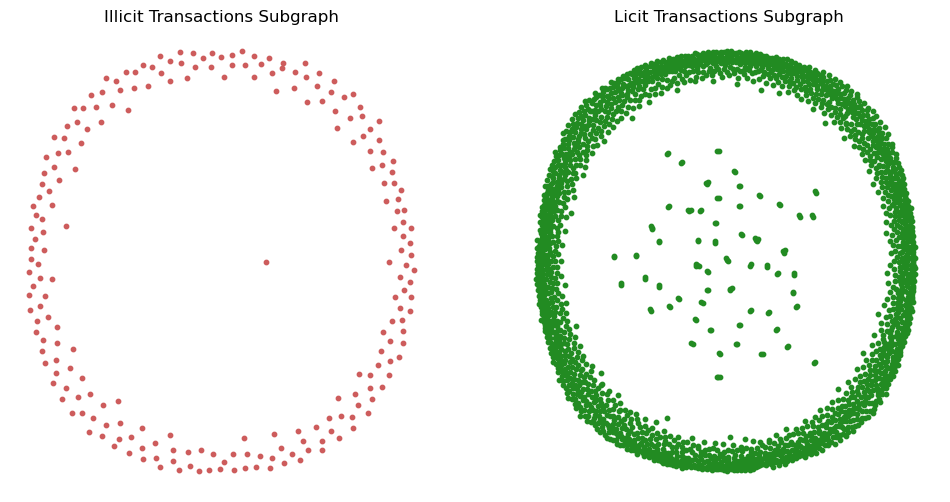

In [598]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
nx.draw(G_illicit, with_labels=False, node_size=10, node_color='indianred', edge_color='black')
plt.title('Illicit Transactions Subgraph')

plt.subplot(1, 2, 2)
nx.draw(G_licit, with_labels=False, node_size=10, node_color='forestgreen', edge_color='black')
plt.title('Licit Transactions Subgraph')

plt.show()

__❌ Illicit Transactions Graph__
- Shows a fairly sparse distribution of nodes, with a ring-like pattern.
- Most nodes are on the periphery, and a few nodes are concentrated in the center.
- Suggests that the __illicit transactions may be less interconnected__, with a __few central nodes potentially acting as hubs__ or key points in the network.

__✅ Licit Transactions Graph__
- The higher density of nodes suggests a more complex network with more transactions or interactions between entities.
- Could imply a more established or legitimate network.
- Suggests that licit transactions may involve more interconnected entities, with many nodes being closely related or interacting more frequently.

# 👥 Community Detection

The goal of community detection is to identify clusters or communities within the graph where nodes are more densely connected internally than with the rest of the graph.

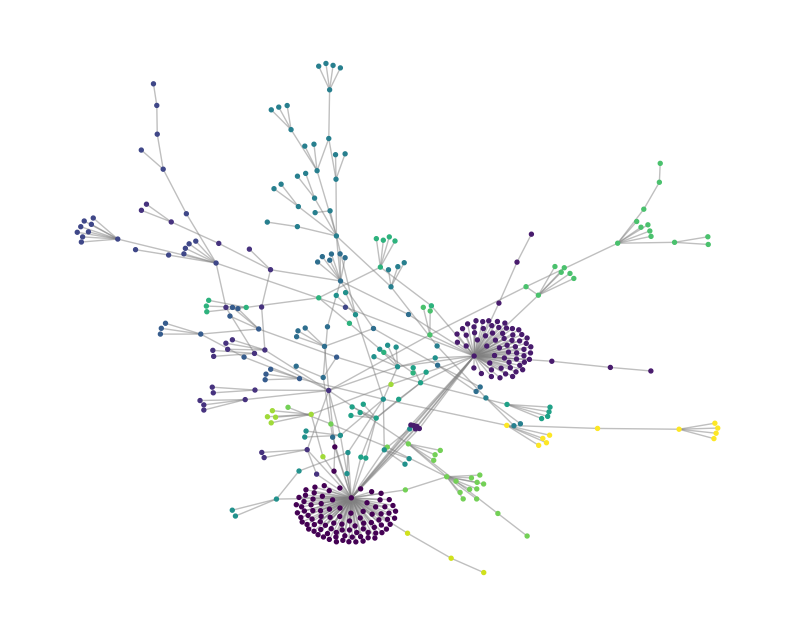

In [599]:
# Compute best partition.
partition = community_louvain.best_partition(G_giant)

# Draw graph.
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G_giant)
cmap = plt.get_cmap('viridis')
nx.draw_networkx_nodes(G_giant, pos, node_color=list(partition.values()), node_size=8, cmap=cmap)
nx.draw_networkx_edges(G_giant, pos, alpha=0.5, edge_color='grey')
plt.axis('off')

plt.show()

# 🧠 Graph Neural Networks 

Graph Neural Networks (GNNs) are a deep learning technique specifically designed for graph data, useful for tasks like node classification, graph classification, or link prediction. In our case, for now, we will perform ___node prediction___.

In [600]:
metrics_per_gnn = {
    'gcn': {
        'val': {
            'precisions': [],
            'probas': [],            
        },
        'test': {
            'licit': {
                'probas': []                
            },
            'illicit': {
                'probas': []                
            }, 
        }
    },
    'gat': {
        'val': {
            'precisions': [],
            'probas': [],            
        },
        'test': {
            'licit': {
                'probas': []                
            },
            'illicit': {
                'probas': []                
            }, 
        }
    },
    'gin': {
        'val': {
            'precisions': [],
            'probas': [],           
        },
        'test': {
            'licit': {
                'probas': []                
            },
            'illicit': {
                'probas': []                
            },            
        }
    }    
}

## 🛠️ Pre-Processing

In [601]:
num_edges = elliptic_txs_edgelist.shape[0]
num_nodes = elliptic_txs_features.shape[0]

print(f'Number of edges in the graph: {num_edges:8,}')
print(f'Number of nodes in the graph: {num_nodes:8,}')

Number of edges in the graph:  234,355
Number of nodes in the graph:  203,769


In [602]:
# --------------------------------------------------------- #
# Create mapping with txId as key and actual index as value #
# --------------------------------------------------------- #

tx_id_mapping = {tx_id: idx for idx, tx_id in enumerate(elliptic_txs_features['txId'])}

edges_with_features = elliptic_txs_edgelist[elliptic_txs_edgelist['txId1'].isin(list(tx_id_mapping.keys()))\
                                          & elliptic_txs_edgelist['txId2'].isin(list(tx_id_mapping.keys()))]

edges_with_features['Id1'] = edges_with_features['txId1'].map(tx_id_mapping)
edges_with_features['Id2'] = edges_with_features['txId2'].map(tx_id_mapping)

edges_with_features

,txId1,txId2,Id1,Id2
0,230425980,5530458,0,1
1,232022460,232438397,2,3
2,230460314,230459870,4,5
3,230333930,230595899,6,7
4,232013274,232029206,8,9
...,...,...,...,...
234350,158365409,157930723,203602,201430
234351,188708874,188708879,203603,203099
234352,157659064,157659046,201921,202042
234353,87414554,106877725,201480,201368


In [603]:
edge_index = torch.tensor(edges_with_features[['Id1', 'Id2']].values.T, dtype=torch.long)
edge_index

tensor([[     0,      2,      4,  ..., 201921, 201480, 201954],
        [     1,      3,      5,  ..., 202042, 201368, 201756]])

In [604]:
# ------------------------------------- #
# Save node features in suitable format #
# ------------------------------------- #

node_features = torch.tensor(elliptic_txs_features.drop(columns=['txId']).values, 
                             dtype=torch.float)
print(node_features.shape)
node_features

torch.Size([203769, 166])


tensor([[ 1.0000e+00, -1.7147e-01, -1.8467e-01,  ..., -9.7524e-02,
         -1.2061e-01, -1.1979e-01],
        [ 1.0000e+00, -1.7148e-01, -1.8467e-01,  ..., -9.7524e-02,
         -1.2061e-01, -1.1979e-01],
        [ 1.0000e+00, -1.7211e-01, -1.8467e-01,  ..., -1.8367e-01,
         -1.2061e-01, -1.1979e-01],
        ...,
        [ 4.9000e+01, -1.7201e-01, -7.8182e-02,  ..., -9.7524e-02,
         -1.2061e-01, -1.1979e-01],
        [ 4.9000e+01, -1.7284e-01, -1.7662e-01,  ..., -1.4060e-01,
          1.5197e+00,  1.5214e+00],
        [ 4.9000e+01, -1.2037e-02, -1.3228e-01,  ..., -1.4060e-01,
          1.5197e+00,  1.5214e+00]])

- 1st dimension tells us about the `# of nodes`
- 2nd dimension tells us about the `# of node features`

In [605]:
elliptic_txs_classes['class'].value_counts()

class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64

In [606]:
# ------------------------ #
# Labelencode target class #
# ------------------------ #

le = LabelEncoder()
class_labels = le.fit_transform(elliptic_txs_classes['class'])
node_labels = torch.tensor(class_labels, dtype=torch.long)
original_labels = le.inverse_transform(class_labels)

print(original_labels)
print(class_labels)
print(node_labels)

['unknown' 'unknown' 'unknown' ... '1' 'unknown' 'unknown']
[2 2 2 ... 0 2 2]
tensor([2, 2, 2,  ..., 0, 2, 2])


In [607]:
print(le.inverse_transform([0])) # illicit
print(le.inverse_transform([1])) # licit 
print(le.inverse_transform([2])) # unknown

['1']
['2']
['unknown']


In [608]:
# ------------------------------------ #
# Create pytorch geometric Data object #
# ------------------------------------ #

data = Data(x=node_features, 
            edge_index=edge_index, 
            y=node_labels)

# Move data to GPU.
data = data.to(device)

Now we have created the [pytorch geometric Data object](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.data.Data.html). However, we still have lots of _unknown_ 🤷 in this object which we dont want to train our GNN on. We only want to train on known nodes, thus, those which are either _licit_ ✅ or _illicit_ ❌. 

In [609]:
known_mask   = (data.y == 0) | (data.y == 1)  # Only nodes with known labels licit or illicit
unknown_mask = data.y == 2                    # Nodes with unknown labels

### Random Split

In [610]:
# ------------------------------------------------ #
# Define size for Training, Validation and Testing #
# ------------------------------------------------ #

num_known_nodes = known_mask.sum().item()
permutations = torch.randperm(num_known_nodes)
train_size = int(0.8 * num_known_nodes)
val_size = int(0.1 * num_known_nodes)
test_size = num_known_nodes - train_size - val_size

total = np.sum([train_size, val_size, test_size])

print(f"""Number of observations per split
    Training   : {train_size:10,} ({100*train_size/total:0.2f} %)
    Validation : {val_size:10,} ({100*val_size/total:0.2f} %)
    Testing    : {test_size:10,} ({100*test_size/total:0.2f} %)
""")

Number of observations per split
    Training   :     37,251 (80.00 %)
    Validation :      4,656 (10.00 %)
    Testing    :      4,657 (10.00 %)



In [611]:
# ----------------------------------------------- #
# Create mask for the indices of Train, Val, Test #
# ----------------------------------------------- #

data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.val_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)

train_indices = known_mask.nonzero(as_tuple=True)[0][permutations[:train_size]]
val_indices = known_mask.nonzero(as_tuple=True)[0][permutations[train_size:train_size + val_size]]
test_indices = known_mask.nonzero(as_tuple=True)[0][permutations[train_size + val_size:]]

data.train_mask[train_indices] = True
data.val_mask[val_indices] = True
data.test_mask[test_indices] = True

data.train_mask

tensor([False, False, False,  ...,  True, False, False])

In [612]:
# -------------------------- #
# Statistics of the datasets #
# -------------------------- #

train_licit, train_illicit = (data.y[data.train_mask] == 1).sum().item(), (data.y[data.train_mask] == 0).sum().item()
val_licit, val_illicit = (data.y[data.val_mask] == 1).sum().item(), (data.y[data.val_mask] == 0).sum().item()
test_licit, test_illicit = (data.y[data.test_mask] == 1).sum().item(), (data.y[data.test_mask] == 0).sum().item()

# Calculate total counts.
train_total = train_licit + train_illicit
val_total = val_licit + val_illicit
test_total = test_licit + test_illicit

# Calculate percentages.
train_licit_pct = (train_licit / train_total) * 100
train_illicit_pct = (train_illicit / train_total) * 100
val_licit_pct = (val_licit / val_total) * 100
val_illicit_pct = (val_illicit / val_total) * 100
test_licit_pct = (test_licit / test_total) * 100
test_illicit_pct = (test_illicit / test_total) * 100

pd.DataFrame({
    'Set': ['Training', 'Validation', 'Testing'],
    'Total Count': [train_total, val_total, test_total],
    'Licit': [train_licit, val_licit, test_licit],
    'Licit (%)': [train_licit_pct, val_licit_pct, test_licit_pct],
    'Illicit': [train_illicit, val_illicit, test_illicit],
    'Illicit (%)': [train_illicit_pct, val_illicit_pct, test_illicit_pct]
})

,Set,Total Count,Licit,Licit (%),Illicit,Illicit (%)
0,Training,37251,33649,90.330461,3602,9.669539
1,Validation,4656,4148,89.089347,508,10.910653
2,Testing,4657,4222,90.659223,435,9.340777


The percentages are pretty similar over all datasets, which is what we want. 

In [613]:
mapped_classes = np.array(['illicit', 'licit'])

## Temporal Splits
### Chronological Split

In [614]:
# ----- Chronological split based on time steps -----

# time_step should be a 1D numpy array or tensor with length = num_nodes
# Example: if you have it as a numpy array:
# time_step = features_df['time_step'].values
# Extract time step from feature matrix (column 0 of the 166 features)
time_step = data.x[:, 0].cpu().numpy()

if isinstance(time_step, torch.Tensor):
    time_step_np = time_step.cpu().numpy()
else:
    time_step_np = time_step

# labeled nodes only (e.g., y != 2 means not "unknown")
labeled_idx = np.where(data.y.cpu().numpy() != 2)[0]

# define time ranges (you can tweak these boundaries)
train_time_max = 34
val_time_min, val_time_max = 35, 40
test_time_min = 41

train_mask_chrono = np.zeros(data.num_nodes, dtype=bool)
val_mask_chrono   = np.zeros(data.num_nodes, dtype=bool)
test_mask_chrono  = np.zeros(data.num_nodes, dtype=bool)

for idx in labeled_idx:
    t = time_step_np[idx]
    if t <= train_time_max:
        train_mask_chrono[idx] = True
    elif val_time_min <= t <= val_time_max:
        val_mask_chrono[idx] = True
    elif t >= test_time_min:
        test_mask_chrono[idx] = True

data.train_mask_chrono = torch.from_numpy(train_mask_chrono)
data.val_mask_chrono   = torch.from_numpy(val_mask_chrono)
data.test_mask_chrono  = torch.from_numpy(test_mask_chrono)
data.train_mask_chrono.sum(), data.val_mask_chrono.sum(), data.test_mask_chrono.sum()

(tensor(29894), tensor(6697), tensor(9973))

### Rolling Window Split

In [615]:
## Rolling Window Split Based on Time Steps ##

## 1️⃣ - GCN - Graph Convolutional Networks

The core idea of a _Graph Convolutional Networks_ (GCN) is to aggregate features from a node's local neighborhood. The feature aggregation is performed using a convolution operation adapted for graph structures.

$$
H^{(l+1)} = \sigma\left( \tilde{D}^{-\frac{1}{2}} \tilde{A} \tilde{D}^{-\frac{1}{2}} H^{(l)} W^{(l)} \right)
$$

- $H^{(l)}$: Node feature matrix at layer $l$.
- $\tilde{A} = A + I$: Adjacency matrix with added self-loops.
- $\tilde{D}$: Diagonal degree matrix of $\tilde{A}$.
- $W^{(l)}$: Trainable weight matrix at layer $l$.
- $\sigma$: Activation function (e.g., ReLU).

## Experiment Helpers and Initiation

In [616]:
# ------------------------------------------- #
# Training, Evaluation and prediction methods #
# ------------------------------------------- #
from sklearn.metrics import precision_recall_fscore_support, average_precision_score


In [617]:
# -------------- #
# Define the GCN #
# -------------- #

class GCN(torch.nn.Module):
    def __init__(self, num_node_features, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_node_features, 16)
        self.conv2 = GCNConv(16, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


# ---------- #
# Initialize #
# ---------- #

## add here ##

model = GCN(num_node_features=data.num_features, num_classes=len(le.classes_)).to(device)
optimizer = torch.optim.Adam(model.parameters(), 
                             lr=0.01, 
                             weight_decay=0.0005)
# Compute class weights using only training labels
# Use the Data object's train_mask and ensure it's on the same device as data.y
if hasattr(data, 'train_mask'):
    train_mask = data.train_mask.to(data.y.device)
else:
    raise AttributeError("data.train_mask not found. Run the cell that creates train/val/test masks before this cell.")

train_labels = data.y[train_mask].cpu().numpy()   # labels for licit/illicit in train set
classes = np.unique(train_labels)

from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)  # Since we have a multiclass classification problem.

data = data.to(device)


model = GCN(num_node_features=data.num_features, num_classes=len(le.classes_)).to(device)
optimizer = torch.optim.Adam(model.parameters(), 
                             lr=0.01, 
                             weight_decay=0.0005)
# Compute class weights using only training labels
labels_np = data.y.cpu().numpy()

# use only labeled nodes (0 = licit, 1 = illicit) to compute weights
labeled_mask = labels_np != 2
train_labels = labels_np[labeled_mask]

# compute weights for classes 0 and 1
weights_01 = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_labels
)  # shape (2,)

# now build a full 3-class weight vector [w_0, w_1, w_2]
full_weights = np.ones(3, dtype=np.float32)
full_weights[0] = weights_01[0]          # licit
full_weights[1] = weights_01[1]          # illicit
full_weights[2] = 0.0                    # unknown (never used in loss, safe to set 0 or 1)

class_weights = torch.tensor(full_weights, dtype=torch.float32).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

data = data.to(device) 



In [618]:
## The train helper function for modelling ##
def train(model, optimizer, train_mask):
    model.train()
    optimizer.zero_grad()

    out = model(data.to(device))  # GCN.forward takes the whole `data` object

    loss = criterion(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate(model, mask):
    """
    Evaluate illicit-class precision, recall, F1, and AUC-PR on nodes
    selected by `mask`, using only labels 0 and 1 (ignoring unknowns).
    Assumes class 1 = illicit, class 0 = non-illicit. The unknown labels usually
    only used for message-passing (to keep the graph structure intact).
    """
    model.eval()

    labels_np = data.y.cpu().numpy()

    # convert mask to numpy
    if isinstance(mask, torch.Tensor):
        mask_np = mask.cpu().numpy()
    else:
        mask_np = mask

    # keep only nodes that:
    #  - are in the mask
    #  - have label 0 or 1 (we explicitly drop anything else)
    valid_idx = mask_np & np.isin(labels_np, [0, 1])

    # if no valid nodes, avoid crashing
    if valid_idx.sum() == 0:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0, "auc_pr": 0.0}

    with torch.no_grad():
        out = model(data.to(device))      # [N, 3] log-probs
        out_np = out.cpu().numpy()

    logits = out_np[valid_idx]
    y_true = labels_np[valid_idx]

    # convert log-softmax to probabilities
    probs = np.exp(logits)
    y_prob = probs[:, 1]                 # probability of class 1 (illicit)
    y_pred = probs.argmax(axis=1)

    # now y_true is guaranteed to be only 0 or 1 → binary is valid
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred,
        average='binary',
        pos_label=1,
        zero_division=0
    )
    auc_pr = average_precision_score(y_true, y_prob)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc_pr": auc_pr
    }


def predict(model, data):
    model.eval()
    with torch.no_grad():
        out = model(data)
        pred = out.argmax(dim=1)
    return pred

def predict_probabilities(model, data):
    model.eval()
    with torch.no_grad():
        out = model(data)
        probabilities = torch.exp(out)
    return probabilities

### Create a NeighborLoader for a given train mask

Tony: James you can modify the following section for your model tuning

In [619]:
def make_train_loader(data, train_mask, batch_size=2048, num_neighbors=[15, 10]):
    """
    Create a NeighborLoader for mini-batch GCN training.
    Only labeled training nodes are used as input seeds.
    Neighbors (possibly unlabeled) are included for message passing.
    """
    # get indices of nodes in the training mask
    if isinstance(train_mask, torch.Tensor):
        train_idx = train_mask.nonzero(as_tuple=False).view(-1)
    else:
        train_idx = torch.from_numpy(train_mask).nonzero(as_tuple=False).view(-1)

    train_loader = NeighborLoader(
        data,
        input_nodes=train_idx,
        num_neighbors=num_neighbors,
        batch_size=batch_size,
        shuffle=True
    )
    return train_loader



def train_minibatch(model, optimizer, train_loader):
    """
    One epoch of mini-batch training using NeighborLoader.
    Loss is computed only on the seed nodes in each batch.
    """
    model.train()
    total_loss = 0.0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        out = model(batch.x, batch.edge_index)

        # Only the first batch.batch_size nodes are the "seeds" we supervise on
        logits_seed = out[:batch.batch_size]
        labels_seed = batch.y[:batch.batch_size]

        loss = criterion(logits_seed, labels_seed)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [620]:
def run_experiment(train_mask, val_mask, test_mask, split_name="random"):
    print(f"\n=== Running GCN on {split_name} split ===")

    # re-initialize model and optimizer for each split
    model = GCN(data.num_features, 3).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    best_val_f1 = 0.0
    best_state = None
    patience = 10
    wait = 0

    for epoch in range(1, 201):
        loss = train(model, optimizer, train_mask)

        metrics_val = evaluate(model, val_mask)
        val_f1 = metrics_val["f1"]

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = model.state_dict()
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val F1: {val_f1:.4f}")

    # load best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics = evaluate(model, test_mask)
    print(f"{split_name} split test metrics:", test_metrics)

    # return BOTH the trained model and its test metrics
    return model, test_metrics


In [621]:
## Second experiment runner with NeighborLoader on mini-batches ##
def run_experiment_minibatch(train_mask, val_mask, test_mask, split_name="random", 
                             batch_size=2048, num_neighbors=[15, 10]):
    print(f"\n=== Running MINI-BATCH GCN on {split_name} split ===")

    model = GCN(data.num_features, 3).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    # build NeighborLoader for this split
    train_loader = make_train_loader(data, train_mask, batch_size=batch_size, num_neighbors=num_neighbors)

    best_val_f1 = 0.0
    best_state = None
    patience = 10
    wait = 0

    for epoch in range(1, 201):
        loss = train_minibatch(model, optimizer, train_loader)

        metrics_val = evaluate(model, val_mask)
        val_f1 = metrics_val["f1"]

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = model.state_dict()
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val F1: {val_f1:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics = evaluate(model, test_mask)
    print(f"{split_name} split test metrics:", test_metrics)
    # return BOTH the trained model and its test metrics
    return model, test_metrics

In [622]:
## Per-time-step evaluation function
# Now define a helper that computes metrics per time step for a trained model
# used for temproal splits

# time_step was already extracted as column 0 of data.x earlier:
# time_step = data.x[:, 0].cpu().numpy()

def evaluate_per_timestep(model, mask, time_step_array, min_support=5):
    """
    Compute precision, recall, F1, and AUC-PR for the illicit class
    at each time step, restricted to nodes selected by `mask`.
    """
    model.eval()

    labels_np = data.y.cpu().numpy()
    if isinstance(mask, torch.Tensor):
        mask_np = mask.cpu().numpy()
    else:
        mask_np = mask

    time_np = time_step_array

    with torch.no_grad():
        out = model(data.x.to(device), data.edge_index.to(device))
        probs_all = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
        preds_all = out.argmax(dim=1).cpu().numpy()

    rows = []
    unique_times = np.sort(np.unique(time_np[mask_np]))

    for t in unique_times:
        idx = (time_np == t) & mask_np & (labels_np != 2)  # labeled nodes in this time step and mask

        if idx.sum() < min_support:
            continue  # skip very small samples to avoid unstable metrics

        y_true = labels_np[idx]
        y_prob = probs_all[idx]
        y_pred = preds_all[idx]

        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average='binary', pos_label=1, zero_division=0
        )
        auc_pr = average_precision_score(y_true, y_prob)

        rows.append({
            "time_step": int(t),
            "n_nodes": int(idx.sum()),
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "auc_pr": auc_pr
        })

    return pd.DataFrame(rows)

In [623]:
# ----- #
# Train #
# ----- #

# train_val_metrics = train_gnn(NUM_EPOCHS, 
#                               data, 
#                               model, 
#                               optimizer, 
#                               criterion)

# metrics_per_gnn['gcn']['val']['precisions'] = train_val_metrics['val']['precisions']

In [624]:
# -------- #
# Evaluate #
# -------- #

# model.eval()
# with torch.no_grad():
    
#     test_metrics = evaluate(model, data, data.test_mask)
#     test_acc = test_metrics.get('accuracy')
#     test_prec = test_metrics.get('precision')
#     test_rec = test_metrics.get('recall')
#     test_f1 = test_metrics.get('f1_score')

#     print(f'Test Acc: {test_acc:.4f} - Prec: {test_prec:.4f} - Rec: {test_rec:.4f} - F1: {test_f1:.4f}')

In [625]:
# plot_train_val_test_metrics(train_val_metrics, test_metrics, NUM_EPOCHS)

In [626]:
# train_pred = predict(model, data)[data.train_mask]
# test_pred = predict(model, data)[data.test_mask]

In [627]:
# print(le.inverse_transform([0])) # illicit
# print(le.inverse_transform([1])) # licit 
# print(le.inverse_transform([2])) # unknown

In [628]:
# # --- Classification report ---
# print("Classification Report")
# print("=====================\n")

# # Train.
# y_true_train = data.y[data.train_mask].cpu().numpy()
# y_pred_train = train_pred.cpu().numpy()

# report_train = classification_report(y_true_train, y_pred_train, target_names=mapped_classes)

# print(f"{4*' '}TRAIN")
# print("---------")
# print(report_train)

# # Test.
# y_true_test = data.y[data.test_mask].cpu().numpy()
# y_pred_test = test_pred.cpu().numpy()

# report_test = classification_report(y_true_test, y_pred_test, target_names=mapped_classes)

# print(f"{4*' '}TEST")
# print("--------")
# print(report_test)

In [629]:
mapped_classes = np.array(['illicit', 'licit'])

# # --- Confusion matrix ---
# cm = confusion_matrix(data.y[data.test_mask].cpu(), test_pred.cpu())

# fig, ax = plt.subplots(figsize=(6, 4))

# sns.heatmap(cm, annot=True, fmt='g', cmap=plt.cm.Greens, 
#             annot_kws={'size': 15}, 
#             xticklabels=mapped_classes,
#             yticklabels=mapped_classes, 
#             linecolor='black', linewidth=0.5,
#             ax=ax)
# plt.xlabel('Predicted Class')
# plt.ylabel('Actual Class')

# # Annotate each cell with the percentage of that row.
# cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# for i in range(cm.shape[0]):
#     for j in range(cm.shape[1]):
#         count = cm[i, j]
#         percentage = cm_normalized[i, j] * 100
#         text = f'\n({percentage:.1f}%)'
#         color = 'white' if percentage > 95 else 'black'
#         ax.text(j + 0.5, i + 0.6, text,
#                 ha='center', va='center', fontsize=10, color=color)

# plt.title('Confusion Matrix (Test set)\nGraph Convolutional Network (GCN)')
# plt.show()

- The model is very good at predicting `unknown` class. Simply because it's the majority of the dataset.
- The GCN is also decent at predicting if a node is `licit` or not. However, it predicted 42% of all `licit` nodes as being `unknown`. 
- The model is decent but unsure at predicting `illicit` nodes. It only classified 46% of all `illicit` nodes correctly.

In [630]:
# train_probas = predict_probabilities(model, data)[data.train_mask]
# test_probas = predict_probabilities(model, data)[data.test_mask]

In [631]:
# train_probas_illicit = train_probas[:, 1].cpu().numpy()
# train_probas_illicit

In [632]:
# ALPHA = 0.1

# train_probas_licit = train_probas[:, 0].cpu().numpy()
# train_probas_illicit = train_probas[:, 1].cpu().numpy()

# test_probas_licit = test_probas[:, 0].cpu().numpy()
# test_probas_illicit = test_probas[:, 1].cpu().numpy()

# metrics_per_gnn['gcn']['test']['licit']['probas'] = test_probas_licit
# metrics_per_gnn['gcn']['test']['illicit']['probas'] = test_probas_illicit

# # -------- #
# # Plotting #
# # -------- #

# plt.figure(figsize=(7, 4))

# # Plot licit class probabilities
# sns.kdeplot(train_probas_licit, fill=True, color="forestgreen", linestyle='-', alpha=ALPHA, label="Training - Licit")
# sns.kdeplot(test_probas_licit, fill=True, color="green", linestyle='--', alpha=ALPHA, label="Test - Licit")

# # Plot illicit class probabilities
# sns.kdeplot(train_probas_illicit, fill=True, color="salmon", linestyle='-', alpha=ALPHA, label="Training - Illicit")
# sns.kdeplot(test_probas_illicit, fill=True, color="red", linestyle='--', alpha=ALPHA, label="Test - Illicit")

# plt.title("GCN - Predicted Probabilities")
# plt.xlabel("Predicted Probability")
# plt.ylabel("Density")
# plt.legend(loc="upper center")

# plt.show()

In [633]:
labels_np = data.y.cpu().numpy()
val_mask_np = data.val_mask.cpu().numpy()
print("Unique labels in val set:", np.unique(labels_np[val_mask_np]))

Unique labels in val set: [0 1]


In [634]:
### Run Experiments

model_random, metrics_random = run_experiment(
    data.train_mask,
    data.val_mask,
    data.test_mask,
    split_name="random"
)

model_chrono, metrics_chrono = run_experiment(
    data.train_mask_chrono,
    data.val_mask_chrono,
    data.test_mask_chrono,
    split_name="chronological"
)
metrics_per_split = {
    'random': metrics_random,
    'chronological': metrics_chrono
}



=== Running GCN on random split ===


ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

In [64]:
## Run Experiments - Full-batch and Mini-batch GCNs (with NeighborLoader) 
# James you can change this if you want##
# Full-batch GCN on random split
model_random_full, metrics_random_full = run_experiment(
    data.train_mask,
    data.val_mask,
    data.test_mask,
    split_name="random-full"
)

# Full-batch GCN on chronological split
model_chrono_full, metrics_chrono_full = run_experiment(
    data.train_mask_chrono,
    data.val_mask_chrono,
    data.test_mask_chrono,
    split_name="chrono-full"
)

# Mini-batch GCN on random split
metrics_random_mb = run_experiment_minibatch(
    data.train_mask,
    data.val_mask,
    data.test_mask,
    split_name="random-minibatch",
    batch_size=2048,
    num_neighbors=[15, 10]
)

# Mini-batch GCN on chronological split
metrics_chrono_mb = run_experiment_minibatch(
    data.train_mask_chrono,
    data.val_mask_chrono,
    data.test_mask_chrono,
    split_name="chrono-minibatch",
    batch_size=2048,
    num_neighbors=[15, 10]
)

NameError: name 'run_experiment' is not defined

### Temporal Splits Results

In [ ]:
## Overall metrics summary ##
results = []

results.append({
    "split": "random-full",
    **metrics_random_full
})

results.append({
    "split": "chrono-full",
    **metrics_chrono_full
})

# If you ran mini-batch:
# results.append({"split": "random-minibatch", **metrics_random_mb})
# results.append({"split": "chrono-minibatch", **metrics_chrono_mb})

df_results = pd.DataFrame(results)
display(df_results)

In [ ]:
##Compute per–time-step metrics for the chronological split##
df_chrono_time = evaluate_per_timestep(
    model_chrono_full,
    data.test_mask_chrono,
    time_step
)

display(df_chrono_time.head())


import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(df_chrono_time["time_step"], df_chrono_time["recall"], marker="o", label="Recall")
plt.plot(df_chrono_time["time_step"], df_chrono_time["f1"], marker="s", label="F1 score")

plt.xlabel("Time step")
plt.ylabel("Score")
plt.title("Chronological split: illicit-class performance over time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(df_chrono_time["time_step"], df_chrono_time["auc_pr"], marker="^", label="AUC-PR")

plt.xlabel("Time step")
plt.ylabel("AUC-PR")
plt.title("Chronological split: illicit-class AUC-PR over time")
plt.grid(True)
plt.tight_layout()
plt.show()